#EduPredict AI: Student Exam Result Prediction using TensorFlow 2.0

Build a simple AI model that predicts whether a student will PASS or FAIL based on:

*   Study Hours
*   Attendance Percentage
*   Sleep Hours
*   Assignment Submission

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [2]:
# Define the dataset
data = {
    'Study Hours': [
        3, 5, 2, 6, 4, 7, 3, 5, 2, 6,
        4, 7, 3, 5, 2, 6, 4, 7, 3, 5,
        8, 9, 7, 6, 5, 8, 9, 7, 6, 5,
        4, 3, 2, 1, 0, 4, 3, 2, 1, 0,
        5, 6, 7, 8, 9, 5, 6, 7, 8, 9,
        1, 2, 3, 4, 5, 1, 2, 3, 4, 5,
        6, 7, 8, 9, 10, 6, 7, 8, 9, 10,
        2, 4, 6, 8, 10, 2, 4, 6, 8, 10,
        3, 6, 9, 1, 4, 3, 6, 9, 1, 4
    ],
    'Attendance Percentage': [
        70, 85, 60, 90, 75, 95, 65, 80, 55, 88,
        72, 92, 68, 82, 58, 87, 78, 93, 63, 81,
        90, 95, 88, 80, 75, 92, 98, 89, 83, 77,
        50, 45, 40, 30, 20, 52, 48, 42, 35, 25,
        70, 75, 80, 85, 90, 72, 78, 82, 88, 93,
        30, 35, 40, 45, 50, 32, 38, 42, 48, 52,
        80, 85, 90, 95, 100, 82, 88, 92, 98, 99,
        40, 50, 60, 70, 80, 45, 55, 65, 75, 85,
        60, 70, 80, 40, 50, 65, 75, 85, 45, 55
    ],
    'Sleep Hours': [
        7, 6, 8, 7, 6, 8, 7, 6, 8, 7,
        6, 8, 7, 6, 8, 7, 6, 8, 7, 6,
        7, 8, 6, 7, 8, 6, 7, 8, 6, 7,
        5, 6, 7, 8, 9, 5, 6, 7, 8, 9,
        7, 6, 5, 4, 3, 7, 6, 5, 4, 3,
        8, 7, 6, 5, 4, 8, 7, 6, 5, 4,
        6, 7, 8, 9, 10, 6, 7, 8, 9, 10,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6
    ],
    'Assignment Submission': [
        8, 7, 6, 9, 7, 9, 6, 8, 5, 8,
        7, 9, 6, 8, 6, 8, 7, 9, 6, 8,
        9, 10, 8, 7, 6, 9, 10, 8, 7, 6,
        4, 3, 2, 1, 0, 4, 3, 2, 1, 0,
        7, 8, 9, 10, 9, 7, 8, 9, 10, 9,
        2, 3, 4, 5, 6, 2, 3, 4, 5, 6,
        8, 9, 10, 9, 8, 8, 9, 10, 9, 8,
        5, 6, 7, 8, 9, 5, 6, 7, 8, 9,
        6, 7, 8, 5, 6, 7, 8, 9, 6, 7
    ],
    'Result': [
        1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
        1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 0, 1, 1, 1, 1, 0, 1
    ]
}

df = pd.DataFrame(data)

display(df.head())

,Study Hours,Attendance Percentage,Sleep Hours,Assignment Submission,Result
0,3,70,7,8,1
1,5,85,6,7,1
2,2,60,8,6,0
3,6,90,7,9,1
4,4,75,6,7,1


In [3]:
# Separate features (X) and target (y)
X = df.drop('Result', axis=1) # Features are all columns except 'Result'
y = df['Result'] # Target is the 'Result' column

# Display the first few rows of X and y to confirm
print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Study Hours,Attendance Percentage,Sleep Hours,Assignment Submission
0,3,70,7,8
1,5,85,6,7
2,2,60,8,6
3,6,90,7,9
4,4,75,6,7



Target (y) head:


,Result
0,1
1,1
2,0
3,1
4,1


In [4]:
# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the resulting sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (72, 4)
X_test shape: (18, 4)
y_train shape: (72,)
y_test shape: (18,)


In [5]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training features and transform both training and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the first few rows of the scaled training data to confirm
print("Scaled X_train (first 5 rows):\n")
print(X_train_scaled[:5])

Scaled X_train (first 5 rows):

[[ 0.86462293  1.0326795   0.32105507  1.09657853]
 [ 0.46038364  0.62610165  0.32105507  0.19937791]
 [ 0.05614435  0.3719905   1.11815731 -0.24922239]
 [-0.34809495 -0.89856528 -0.47604717 -0.24922239]
 [-1.56081283 -1.81336543  1.11815731 -2.04362362]]


In [6]:
# Initialize the Sequential model
model = Sequential()

# Add the input layer and first hidden layer
# The input_dim is the number of features in our dataset (X_train_scaled.shape[1])
model.add(Dense(units=16, activation='relu', input_dim=X_train_scaled.shape[1]))

# Add a second hidden layer
model.add(Dense(units=8, activation='relu'))

# Add the output layer
# For binary classification, we use a single unit with a sigmoid activation function
model.add(Dense(units=1, activation='sigmoid'))

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model compiled successfully!")

Model compiled successfully!


In [8]:
# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,  # Train for 50 epochs
    batch_size=8, # Process 8 samples at a time
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1 # Show training progress
)

print("Model training complete!")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8070 - loss: 0.6380 - val_accuracy: 0.6667 - val_loss: 0.6388
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8246 - loss: 0.6143 - val_accuracy: 0.6667 - val_loss: 0.6197
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8421 - loss: 0.5899 - val_accuracy: 0.7333 - val_loss: 0.6000
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8596 - loss: 0.5665 - val_accuracy: 0.7333 - val_loss: 0.5792
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8596 - loss: 0.5397 - val_accuracy: 0.8000 - val_loss: 0.5592
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8772 - loss: 0.5127 - val_accuracy: 0.8667 - val_loss: 0.5369
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8947 - loss: 0.4848 - val_accuracy: 0.8667 - val_loss: 0.5122
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8947 - loss: 0.4560 - val_accuracy: 0.8667 - val_loss: 0.4858
Epoch

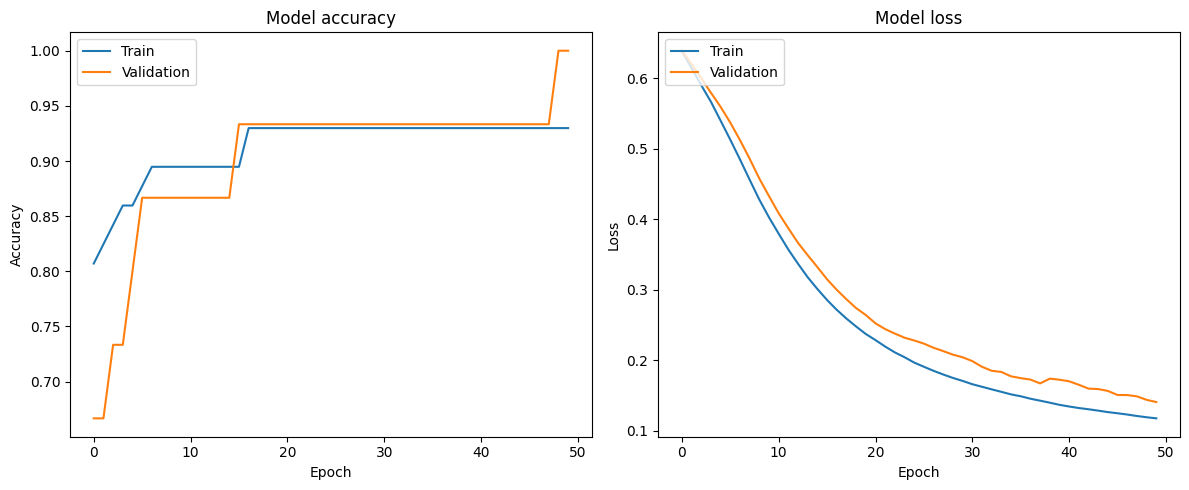

In [9]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [10]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

# Display the evaluation results
print(f"Model Loss on Test Data: {loss:.4f}")
print(f"Model Accuracy on Test Data: {accuracy:.4f}")

Model Loss on Test Data: 0.1106
Model Accuracy on Test Data: 0.9444


In [16]:
# Function to get user input for a new student
def get_student_input():
    print("\nEnter new student details for prediction:")
    try:
        study_hours = float(input("Enter Study Hours (e.g., 5.0): "))
        attendance_percentage = float(input("Enter Attendance Percentage (e.g., 85.0): "))
        sleep_hours = float(input("Enter Sleep Hours (e.g., 7.0): "))
        assignment_submission = float(input("Enter Assignment Submission (e.g., 8.0): "))

        # Create a Pandas DataFrame for the new student's data
        new_student_data = pd.DataFrame([{
            'Study Hours': study_hours,
            'Attendance Percentage': attendance_percentage,
            'Sleep Hours': sleep_hours,
            'Assignment Submission': assignment_submission
        }])
        return new_student_data
    except ValueError:
        print("Invalid input. Please enter numeric values.")
        return None

# Get new student data from user
new_student = get_student_input()

if new_student is not None:
    print("\nNew Student Data:")
    display(new_student)


Enter new student details for prediction:
Enter Study Hours (e.g., 5.0): 1
Enter Attendance Percentage (e.g., 85.0): 50
Enter Sleep Hours (e.g., 7.0): 3
Enter Assignment Submission (e.g., 8.0): 6

New Student Data:


,Study Hours,Attendance Percentage,Sleep Hours,Assignment Submission
0,1.0,50.0,3.0,6.0


In [17]:
if new_student is not None:
    # Scale the new student's data using the *fitted* scaler
    new_student_scaled = scaler.transform(new_student)

    # Make a prediction using the trained model
    prediction_probability = model.predict(new_student_scaled)[0][0]

    # Determine the final result based on a threshold (e.g., 0.5)
    predicted_result = "Pass" if prediction_probability >= 0.5 else "Fail"

    print(f"\nPrediction Probability: {prediction_probability:.4f}")
    print(f"Predicted Result for New Student: {predicted_result}")
else:
    print("Could not make a prediction due to invalid input.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Prediction Probability: 0.2689
Predicted Result for New Student: Fail
